# `HC_statics.py` — Static Hot-Carrier Simulation

This notebook walks through the full simulation pipeline defined in `HC_statics.py`:

```
build_cluster        →  BCMObject list   (geometry)
get_polarizations    →  (k, E) pairs     (distinct illumination channels)
BCM solve            →  X_lm(omega)      (field coefficients)
hot_e_dist           →  Te, Th, Mfi2     (hot-carrier distributions)
hot_carriers_plot    →  static snapshot  (at fixed lifetime tau)
hot_carrier_dynamics →  GIF over tau_e   (dynamics)
```

Each section mirrors one block in `HC_statics.py` and explains the physics behind it.

| Parameter | Default | What it controls |
|---|---|---|
| `STRUCTURE` | 7 | cluster topology (2/3/4/5/7 spheres) |
| `D` | 5.0 nm | sphere diameter |
| `SIM_GAPS` | [1.0] | surface-to-surface gaps to run |
| `SWEEP_MODE` | None | diameter sweep type |
| `plot_flag` | `'both'` | static / dynamics / both |

## Step 0 — Imports

In [1]:
import numpy as np
from scipy.constants import hbar, eV, speed_of_light
from scipy.constants import physical_constants
import matplotlib.pyplot as plt
import warnings

import plytrons.bcm_sphere as bcm
from plytrons.bcm_sphere import EField, BCMObject
from plytrons.plot_utils import (
    make_results_folder,
    plot_spheres,
    plot_transition_matrix_colormap,
    plot_Ne_cdf_steps,
    hot_carrier_dynamics_plot,
    hot_carriers_plot,
    build_cluster,
    get_polarizations,
)
from plytrons.hot_carriers import hot_e_dist, hot_e_cdf_per_photon
from plytrons.math_utils import eps0
from scipy.signal import find_peaks
import plytrons.quantum_well as qw

from numba.core.errors import NumbaTypeSafetyWarning
warnings.simplefilter('ignore', category=NumbaTypeSafetyWarning)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120})

---
## Step 1 — Configuration block

Edit **only this cell** to change the simulation.  Everything else adapts automatically.

**`SWEEP_MODE` options:**

| Value | Behaviour |
|---|---|
| `None` | single diameter `D`, loop over `SIM_GAPS` |
| `'fixed_gap'` | loop over `SWEEP_D` diameters, gap fixed at `FIXED_GAP` |
| `'fixed_centers'` | loop over `SWEEP_D`, gap = `FIXED_DC − D` (fixed centre-to-centre) |

In [2]:
# ── Cluster geometry ─────────────────────────────────────────────────────────
STRUCTURE  = 7          # 2 | 3 | 4 | 5 | 7
D          = 5.0        # sphere diameter (nm)
SIM_GAPS   = [1.0]      # gap values (nm) when SWEEP_MODE is None

# ── Diameter sweep (optional) ─────────────────────────────────────────────────
SWEEP_MODE = None       # None | 'fixed_gap' | 'fixed_centers'
SWEEP_D    = [5, 7, 10, 15, 20]   # diameters for sweep (nm)
FIXED_GAP  = 1.0        # gap (nm) used when SWEEP_MODE == 'fixed_gap'
FIXED_DC   = 8.0        # centre-to-centre (nm) used when SWEEP_MODE == 'fixed_centers'

# ── BCM / material ───────────────────────────────────────────────────────────
lmax       = 10
eps_h      = 1.0        # host permittivity (vacuum)

# ── Hot-carrier output ────────────────────────────────────────────────────────
plot_flag  = 'both'     # 'static' | 'dynamics' | 'both'
tau        = 500        # fs  — lifetime for static snapshot
dE_factor  = 5          # Lorentzian broadening factor (× grid step)
delta_E    = 4.0        # energy window around E_F for plots (eV)

---
## Step 2 — Physical constants and Drude model

Silver Drude parameters: $\hbar\omega_p = 9.07$ eV, $\hbar\gamma = 0.060$ eV, $\varepsilon_b = 4.18$.

In [4]:
c0   = speed_of_light
Z0, *_ = physical_constants['characteristic impedance of vacuum']
Z0   = Z0 * eV   # project units: e/V-s

wp   = 9.07  * eV / hbar
gw   = 0.060 * eV / hbar
eps_b = 4.18

def eps_drude(x):
    return eps_b - (wp**2) / ((2*np.pi*c0 / x*1E6) * ((2*np.pi*c0 / x * 1E6) + 1j * gw))

# Frequency axis
w      = np.linspace(2.5, 5.0, 1000) * eV / hbar   # [rad/s]
lam_um = 2 * np.pi * 3E14 / w                        # [um]
hv_eV  = w * hbar / eV                               # [eV]

# Hot-carrier lifetime grid
tau_e = np.linspace(50, 1500, 59)          # [fs]
idx   = np.abs(tau_e - tau).argmin()       # index closest to requested tau

print(f'Frequency range: {hv_eV[0]:.2f} – {hv_eV[-1]:.2f} eV  ({len(w)} points)')
print(f'tau_e grid: {tau_e[0]:.0f} – {tau_e[-1]:.0f} fs  ({len(tau_e)} points)')
print(f'Static snapshot at tau = {tau} fs  (index {idx}, actual {tau_e[idx]:.0f} fs)')

Frequency range: 2.50 – 5.00 eV  (1000 points)
tau_e grid: 50 – 1500 fs  (59 points)
Static snapshot at tau = 500 fs  (index 18, actual 500 fs)


---
## Step 3 — Build diameter and gap lists from `SWEEP_MODE`

This mirrors the sweep-mode logic in `HC_statics.py` exactly.

In [5]:
if SWEEP_MODE is None:
    diameter_list = [D]
    gap_map       = {D: list(SIM_GAPS)}

elif SWEEP_MODE == 'fixed_gap':
    diameter_list = list(SWEEP_D)
    gap_map       = {Dv: [FIXED_GAP] for Dv in diameter_list}

elif SWEEP_MODE == 'fixed_centers':
    diameter_list = list(SWEEP_D)
    gap_map = {}
    for Dv in diameter_list:
        g = FIXED_DC - Dv
        if g <= 0:
            raise ValueError(
                f'SWEEP_MODE=fixed_centers: gap = {FIXED_DC} - {Dv} = {g} nm <= 0. '
                'Increase FIXED_DC or reduce max diameter in SWEEP_D.'
            )
        gap_map[Dv] = [g]

else:
    raise ValueError(f'Unknown SWEEP_MODE={SWEEP_MODE!r}')

print(f'Diameters to run : {diameter_list}')
for Dv, gaps in gap_map.items():
    print(f'  D = {Dv} nm  ->  gaps = {gaps} nm')

Diameters to run : [5.0]
  D = 5.0 nm  ->  gaps = [1.0] nm


---
## Step 4 — Cluster geometry and polarization channels

`build_cluster` returns ready-to-use `BCMObject` instances with verified NN gaps.  
`get_polarizations` returns only the physically distinct `(k_hat, e_hat)` pairs — no redundant illumination directions are run.

In [6]:
# Preview geometry and polarizations for the first (D, gap) combination
D_preview    = diameter_list[0]
gap_preview  = gap_map[D_preview][0]

BCM_preview  = build_cluster(STRUCTURE, D_preview, gap_preview, lmax, eps_drude, eps_h)
polarizations = get_polarizations(STRUCTURE)

print(f'Structure : {STRUCTURE}-sphere cluster')
print(f'D = {D_preview} nm,  gap = {gap_preview} nm,  d_c = {D_preview + gap_preview} nm')
print(f'lmax = {lmax}')
print()
print(f'Spheres ({len(BCM_preview)}):')
for o in BCM_preview:
    p = o.position
    print(f'  {o.label:8s}  pos = ({p[0]:6.2f}, {p[1]:6.2f}, {p[2]:6.2f}) nm')
print()
print(f'Polarizations ({len(polarizations)}):')
for k, e in polarizations:
    print(f'  k = {k}   E = {e}')

Structure : 7-sphere cluster
D = 5.0 nm,  gap = 1.0 nm,  d_c = 6.0 nm
lmax = 10

Spheres (7):
  Sphere1   pos = (  0.00,   0.00,   0.00) nm
  Sphere2   pos = (  0.00,   0.00,   6.00) nm
  Sphere3   pos = (  0.00,  -5.20,   3.00) nm
  Sphere4   pos = (  0.00,  -5.20,  -3.00) nm
  Sphere5   pos = (  0.00,  -0.00,  -6.00) nm
  Sphere6   pos = (  0.00,   5.20,  -3.00) nm
  Sphere7   pos = (  0.00,   5.20,   3.00) nm

Polarizations (2):
  k = [1. 0. 0.]   E = [0. 1. 0.]
  k = [1. 0. 0.]   E = [0. 0. 1.]


---
## Step 5 — Geometry visualisation

`plot_spheres` draws the cluster with the incident field vectors.

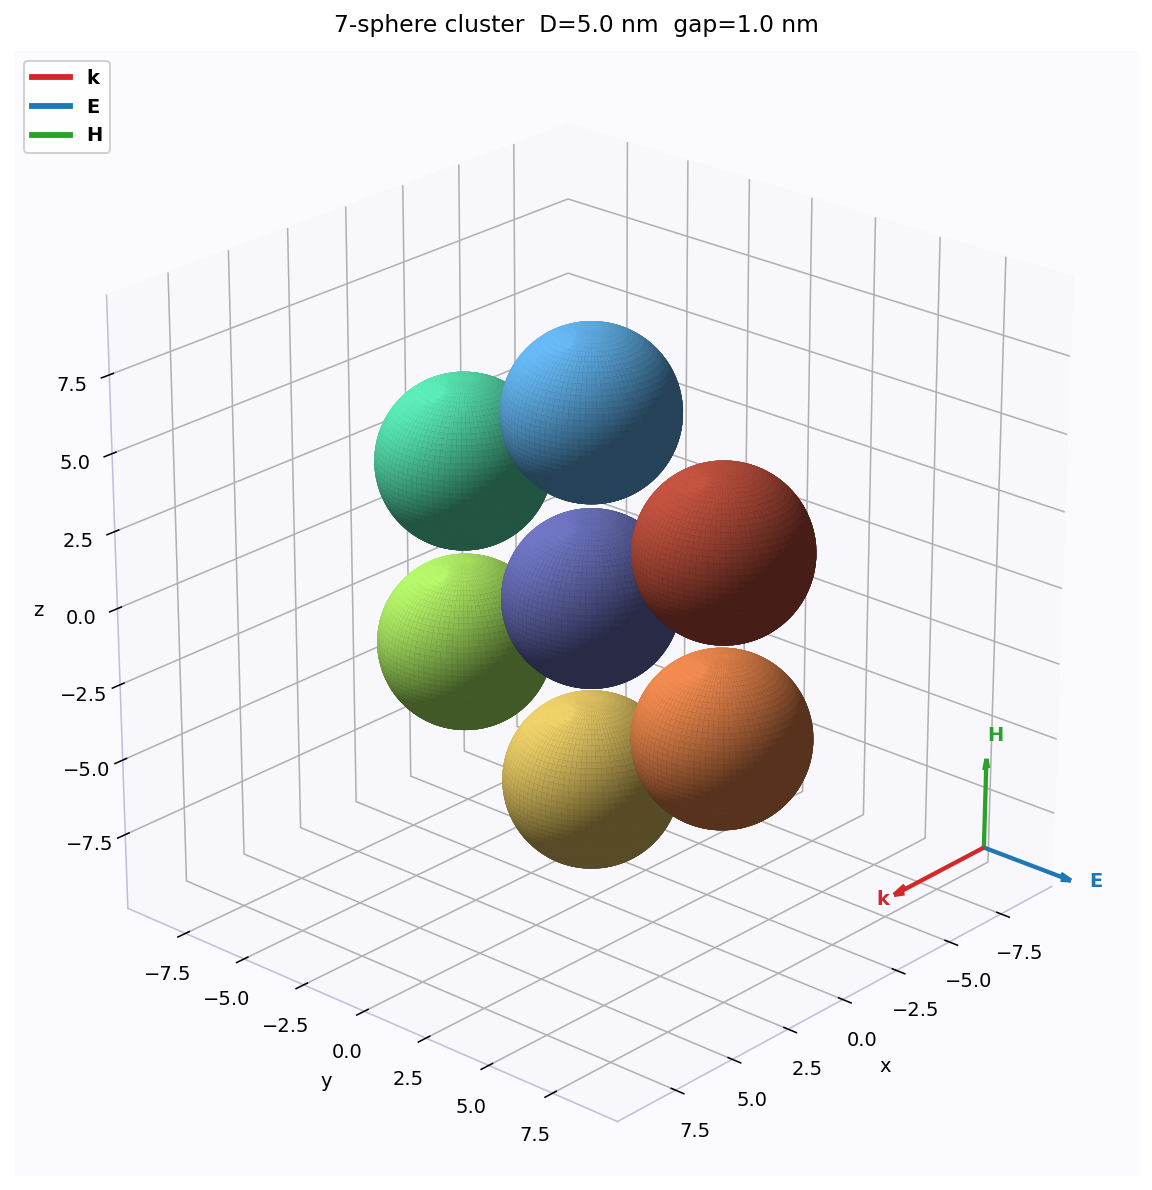

In [7]:
k_hat0, e_hat0 = polarizations[0]
efield0 = EField(E0=1, k_hat=bcm.v_normalize(k_hat0), e_hat=bcm.v_normalize(e_hat0))
pos_preview = np.array([o.position for o in BCM_preview], dtype=float)

fig, ax = plot_spheres(
    pos_preview, radii=None,
    cmap_name='turbo',
    light_dir=(1, -1, 2.2),
    title=f'{STRUCTURE}-sphere cluster  D={D_preview} nm  gap={gap_preview} nm',
    k_vec=efield0.k_hat, E_vec=efield0.e_hat, draw_H=True,
    origin_mode='corner', corner=('min', 'max', 'min'),
    corner_inset=0.15, offset_along_k=0.15,
    show=True,
)
plt.show()

---
## Step 6 — BCM solve (single D, gap, polarization)

The geometry matrices $G^{\rm int}$ and $G^{\rm ext}$ are frequency-independent and computed once per geometry.  The frequency loop calls `solve_BCM` at each $\omega$.

We run the first entry from the diameter/gap/polarization lists as a worked example.

In [8]:
D_run   = diameter_list[0]
delta_  = gap_map[D_run][0]
k_hat, e_hat = polarizations[0]

BCM_objects = build_cluster(STRUCTURE, D_run, delta_, lmax, eps_drude, eps_h)
Np_cluster  = len(BCM_objects)
pos         = np.array([o.position for o in BCM_objects], dtype=float)

efield = EField(E0=1, k_hat=bcm.v_normalize(k_hat), e_hat=bcm.v_normalize(e_hat))

# Frequency-independent matrices
Gi = [bcm.Ginternal(BCM_objects[i]) for i in range(Np_cluster)]
G0 = [[bcm.Gexternal(BCM_objects[i], BCM_objects[j])
       for j in range(Np_cluster)] for i in range(Np_cluster)]
Sv = [bcm.Efield_coupling(BCM_objects[i], efield) for i in range(Np_cluster)]

# Frequency loop
dx_max   = lmax * (lmax + 1) + (lmax + 1) - 1
obj_coef = [np.zeros((dx_max, len(w)), dtype=complex) for _ in range(Np_cluster)]
Sw       = [None] * Np_cluster

print(f'Solving BCM for {STRUCTURE}-sphere cluster, D={D_run} nm, gap={delta_} nm ...')
for il in range(len(w)):
    c, Si = bcm.solve_BCM(w[il], eps_h, BCM_objects, efield, Gi, G0, Sv)
    for in_idx in range(Np_cluster):
        obj_coef[in_idx][:, il] = c[in_idx]
        if il == 0:
            Sw[in_idx] = np.zeros((len(Si[in_idx]), len(w)), dtype=complex)
        Sw[in_idx][:, il] = Si[in_idx]

for idx_obj in range(Np_cluster):
    BCM_objects[idx_obj].set_coefficients(lam_um, obj_coef[idx_obj])

Psca, Pabs = bcm.EM_power(w, eps_h, Gi, G0, BCM_objects)
print('Done.')

Solving BCM for 7-sphere cluster, D=5.0 nm, gap=1.0 nm ...
Done.


---
## Step 7 — Per-sphere absorption spectra

$Q_{\rm abs}^{(i)} = P_{\rm abs}^{(i)} / (I_0 \pi R^2)$ for each sphere $i$.

c:\users\pablo\proyectos\plytrons\plytrons\bcm_sphere.py:251: RuntimeWarning: invalid value encountered in true_divide
  vector = np.array(vector) / np.array(vector)


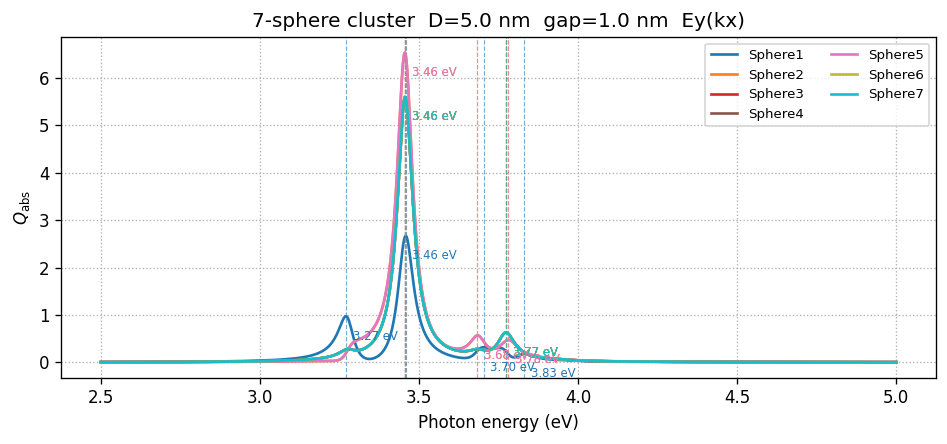

In [9]:
I0 = efield.E0**2 / (2 * Z0)

colors = plt.cm.tab10(np.linspace(0, 1, Np_cluster))
fig, ax = plt.subplots(figsize=(8, 3.8))

for i, obj in enumerate(BCM_objects):
    Ri   = obj.diameter / 2.0
    Qabs = Pabs[i] / (I0 * np.pi * Ri**2)
    ax.plot(hv_eV, Qabs, lw=1.6, color=colors[i], label=obj.label)

    pks, _ = find_peaks(Qabs, height=Qabs.max()*0.05, prominence=Qabs.max()*0.02)
    for pk in pks:
        ax.axvline(hv_eV[pk], lw=0.7, ls='--', color=colors[i], alpha=0.6)
        ax.annotate(f'{hv_eV[pk]:.2f} eV',
                    xy=(hv_eV[pk], Qabs[pk]),
                    xytext=(4, -14), textcoords='offset points',
                    fontsize=7, color=colors[i])

ax.set_xlabel('Photon energy (eV)')
ax.set_ylabel(r'$Q_{\rm abs}$')
ax.set_title(
    f'{STRUCTURE}-sphere cluster  D={D_run} nm  gap={delta_} nm  '
    f'E{bcm.get_axis(efield.e_hat)}(k{bcm.get_axis(efield.k_hat)})'
)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, ls=':')
plt.tight_layout()
plt.show()

---
## Step 8 — Quantum-well bound states

The hot-carrier matrix element depends on the spherical quantum-well eigenstates $(n, \ell)$ of each sphere (same for a homodimer since all spheres have diameter $D$).

In [10]:
a        = D_run / 2
E_matrix = qw.get_bound_states(a)
A_matrix = qw.get_normalization(a, E_matrix)
e_states = qw.e_state_assembly(E_matrix, A_matrix)

lmax_qw = len(e_states)
N_tot   = sum(e_states[l].Eb.size for l in range(lmax_qw))
print(f'a = {a} nm,  QW lmax = {lmax_qw-1},  total states = {N_tot}')

a = 2.5 nm,  QW lmax = 42,  total states = 296


---
## Step 9 — Hot-carrier distribution at the dominant resonance

We pick sphere 1 and its dominant absorption peak, then call `hot_e_dist` to get:

* `Te[tau_idx]`, `Th[tau_idx]` — smoothed hot-electron/hole distributions at lifetime `tau`
* `Te_raw`, `Th_raw` — raw per-state generation rates $\dot{N}_e[f]$
* `Mfi2`, `E_vals` — transition matrix $|M_{fi}|^2$ and energy axis

In [11]:
EF = 5.5   # Fermi level of silver (eV)

# Pick sphere 0, dominant peak
Np_idx    = 0
peaks_pos = find_peaks(Pabs[Np_idx])[0]
if len(peaks_pos) == 0:
    peaks_pos = [int(Pabs[Np_idx].argmax())]
pk        = peaks_pos[int(np.argmax(Pabs[Np_idx][peaks_pos]))]

lam_target = lam_um[pk]
hv         = 2*np.pi*3E14/lam_target * hbar/eV
Pabs_peak  = Pabs[Np_idx][pk] / (np.pi * eps0) * 1e-15   # eV/ps
X_lm       = BCM_objects[Np_idx].coef_at(lam_target)

print(f'Sphere 1  dominant resonance:')
print(f'  lambda = {lam_target*1e3:.1f} nm,  hv = {hv:.3f} eV')
print(f'  Pabs   = {Pabs_peak:.4g} eV/ps')

Te, Th, Te_raw, Th_raw, Mfi2, E_vals, *_ = hot_e_dist(
    a, hv, EF, tau_e, e_states, X_lm, Pabs_peak
)
print('hot_e_dist done.')
print(f'Te shape: {Te.shape}  (tau_e x energy)')

Sphere 1  dominant resonance:
  lambda = 358.7 nm,  hv = 3.458 eV
  Pabs   = 2503 eV/ps


c:\users\pablo\proyectos\plytrons\plytrons\hot_carriers.py:225: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  Mfi_2_block = _M_transition_squared(lf, li, a_nm, X_lm, state_lf, state_li)
c:\users\pablo\proyectos\plytrons\plytrons\hot_carriers.py:225: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  Mfi_2_block = _M_transition_squared(lf, li, a_nm, X_lm, state_lf, state_li)


hot_e_dist done.
Te shape: (59, 296)  (tau_e x energy)


---
## Step 10 — Transition matrix $|M_{fi}|^2$

Shows which initial → final state transitions are optically active at the resonance energy.

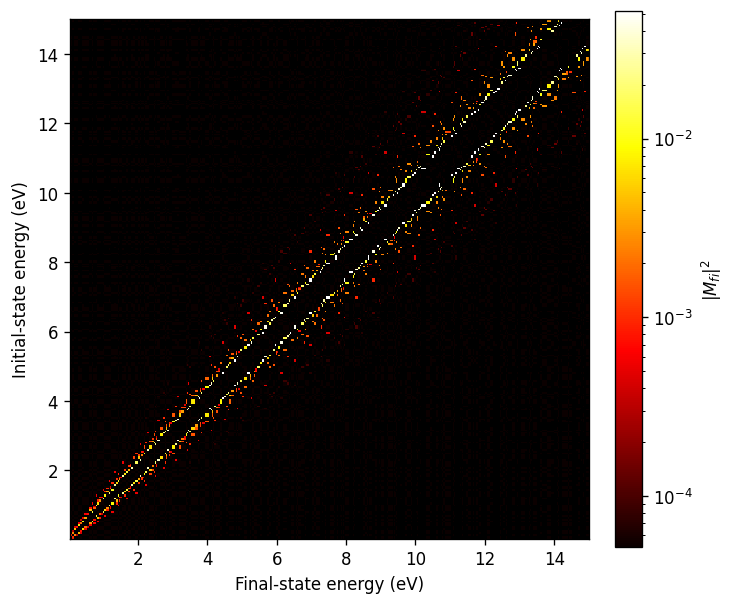

In [14]:
plot_transition_matrix_colormap(
    Mfi2, E_vals,
    dedup='sum', scale='log', qmin=0.001, qmax=0.999
)
plt.show()

---
## Step 11 — Hot-electron yield CDF per photon

$N_e(\varepsilon) = \int_\varepsilon^\infty \dot{N}_e(\varepsilon') d\varepsilon'$ per absorbed photon.

The dashed lines at $0.2\,h\nu$ and $0.5\,h\nu$ mark common injection thresholds.

c:\users\pablo\proyectos\plytrons\plytrons\bcm_sphere.py:251: RuntimeWarning: invalid value encountered in true_divide
  vector = np.array(vector) / np.array(vector)


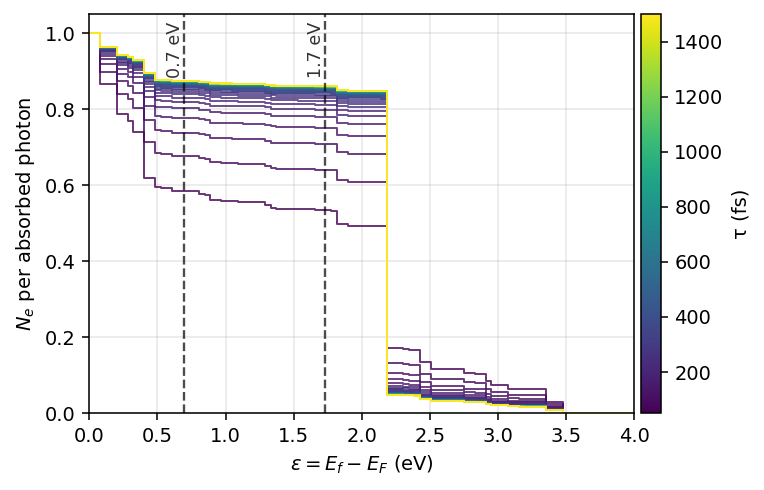

In [15]:
eps_axis = np.linspace(0.0, 4.0, 100)   # eV above E_F

Ne_sel, _ = hot_e_cdf_per_photon(
    Te_raw, e_states, hv, Pabs_peak,
    E_F=EF, eps_eval=eps_axis, relative_to_EF=True
)

outdir = make_results_folder(BCM_objects, efield)

plot_Ne_cdf_steps(
    eps_axis, Ne_sel, tau_e,
    hv=hv,
    Np=Np_idx, peak=1, D=D_run,
    efield=efield,
    out_dir=outdir,
    save_dpi=300,
)
plt.show()

---
## Step 12 — Static hot-carrier snapshot at $\tau =$ `tau` fs

`hot_carriers_plot` shows the smoothed distributions $n_e(\varepsilon)$ and $n_h(\varepsilon)$ at the chosen lifetime, with the raw per-state rates overlaid.

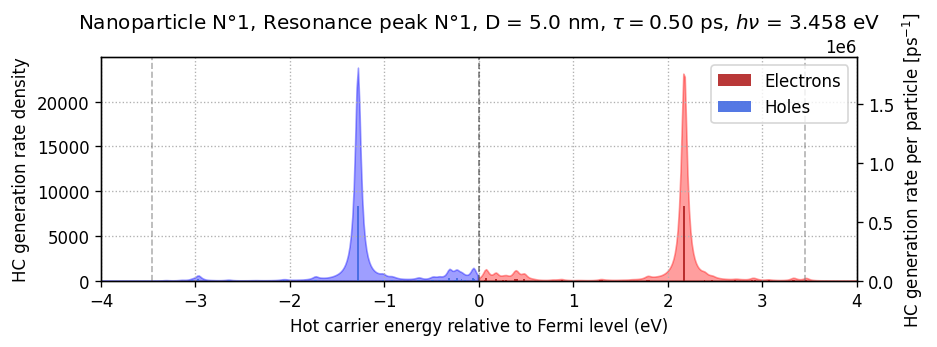

In [16]:
hot_carriers_plot(
    Te[idx], Th[idx], Te_raw[idx], Th_raw[idx],
    e_states, Np_idx+1, 1,
    tau, D_run, hv, EF, dE_factor, delta_E, efield,
    out_path=str(outdir / f'hot_carriers_static_Np1_Res1_tau{tau}.png'),
)
plt.show()

---
## Step 13 — Dynamics GIF over the lifetime grid $\tau_e$

`hot_carrier_dynamics_plot` animates how $n_e(\varepsilon, \tau)$ evolves as the inelastic lifetime increases from 50 to 1500 fs.

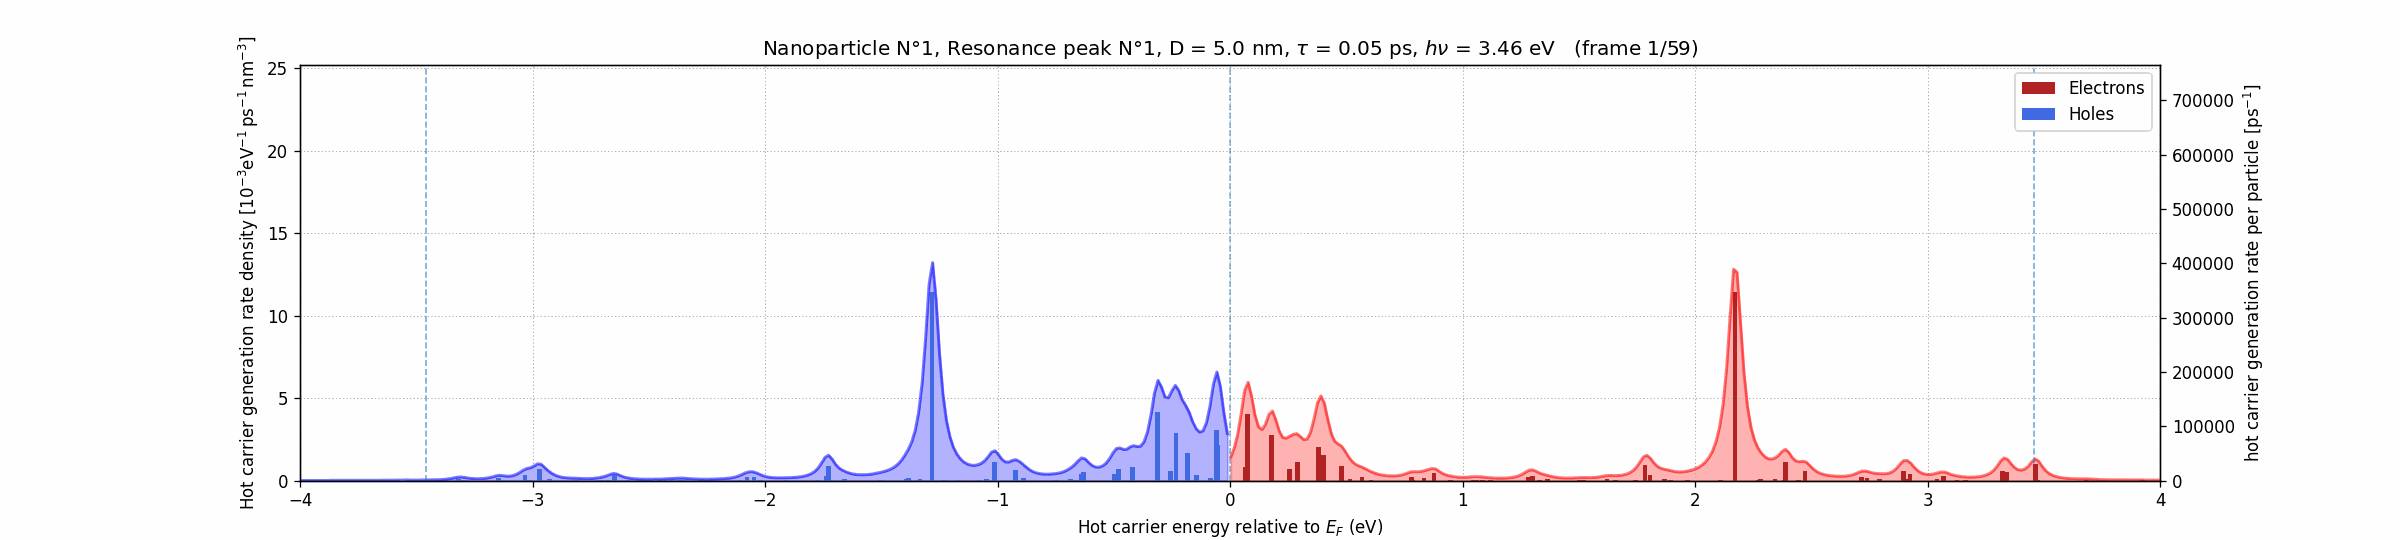

GIF saved to c:\users\pablo\proyectos\plytrons\Results\spherical_NP\Heptamer\static_simulations\heptamer-planar_D5.0nm_gap1.0nm_Eykx


In [17]:
if plot_flag in ['dynamics', 'both']:
    hot_carrier_dynamics_plot(
        Te, Th, Te_raw, Th_raw,
        e_states, Np_idx+1, 1,
        tau_e, D_run, hv, EF,
        dE_factor=dE_factor, delta=delta_E,
        fps=6,
        out_path=str(outdir / 'hot_carriers_dynamics_Np1_Res1.gif'),
    )
    print(f'GIF saved to {outdir}')

---
## Summary

The full pipeline from `HC_statics.py` in one picture:

```
CONFIGURATION BLOCK
  STRUCTURE, D, SIM_GAPS, SWEEP_MODE, ...
       |
       v
build_cluster(STRUCTURE, D, gap, lmax, eps_drude)
  -> BCM_objects  (verified NN gaps)
       |
get_polarizations(STRUCTURE)
  -> [(k, E), ...]  (distinct illumination channels only)
       |
  for D x gap x polarization:
       |
    BCM solve  ->  X_lm(omega), Pabs(omega)
       |
    qw.get_bound_states  ->  e_states
       |
    hot_e_dist(a, hv, EF, tau_e, e_states, X_lm, Pabs_peak)
      -> Te, Th, Mfi2
       |
    hot_carriers_plot   (static)
    hot_carrier_dynamics_plot  (GIF)
    plot_Ne_cdf_steps   (injection yield)
```

| Output file | Content |
|---|---|
| `absorption_spectrum_sphere{i}.png` | $Q_{\rm abs}(\omega)$ per sphere |
| `geometry.png` | 3-D cluster render |
| `geometry.txt` | positions, diameters, field config |
| `hot_carriers_static_*.png` | $n_e, n_h$ at fixed $\tau$ |
| `hot_carriers_dynamics_*.gif` | animated dynamics over $\tau_e$ |
| `Ne_cdf_*.png` | injection yield CDF |